# pythscribe — `@wasm` image filters: ~50× in an interactive lab

Real per-pixel image filters written as `@wasm` Python kernels — **threshold, Sobel, sharpen,
emboss, dilate, erode** — each **~50–100× faster than plain Python**, bit-for-bit correct. The lab
below gives you a **plain-Python slider** and a **`@wasm` slider** side by side: drag both and feel
the difference; every run is recorded and the bottom cell reports the **median speedup**.

Run in the **PythScribe (Gradio)** kernel (`pyths-gradio`). Only pythscribe import: `wasm`.

## The filter kernels (typed-array `uint8`, `@wasm`)

In [1]:
from __future__ import annotations
import time
from pathlib import Path
import numpy as np
from PIL import Image, ImageDraw
from IPython.display import display
from pythscribe import wasm, binding_of

IMG = Path('../gradio-image-preprocess/test_images/photo_640x480.jpg')
rgb0 = np.asarray(Image.open(IMG).convert('RGB'), dtype=np.uint8)
H0, W0 = rgb0.shape[:2]

# Each kernel is a 2-D uint8 typed array [H, W*3] of row-major RGB. Only +/-/* and compares --
# no floor-div (that falls back on uint8), which is why these admit on the fast WASM path.
@wasm
def threshold_lum(img: Array[uint8, 2], out: Array[uint8, 2], h: int, w: int, thr: int) -> int:
    for y in range(h):
        for x in range(w):
            c = x * 3
            s = img[y][c] + img[y][c + 1] + img[y][c + 2]
            v = 0
            if s > thr:
                v = 255
            out[y][c] = v; out[y][c + 1] = v; out[y][c + 2] = v
    return h * w

@wasm
def sobel(img: Array[uint8, 2], out: Array[uint8, 2], h: int, w: int) -> int:
    for y in range(1, h - 1):
        for x in range(1, w - 1):
            c = x * 3
            gx = img[y-1][c+3] + 2*img[y][c+3] + img[y+1][c+3] - img[y-1][c-3] - 2*img[y][c-3] - img[y+1][c-3]
            gy = img[y+1][c-3] + 2*img[y+1][c] + img[y+1][c+3] - img[y-1][c-3] - 2*img[y-1][c] - img[y-1][c+3]
            m = gx
            if m < 0:
                m = -m
            nn = gy
            if nn < 0:
                nn = -nn
            e = m + nn
            if e > 255:
                e = 255
            out[y][c] = e; out[y][c + 1] = e; out[y][c + 2] = e
    return (h - 2) * (w - 2)

@wasm
def sharpen(img: Array[uint8, 2], out: Array[uint8, 2], h: int, w: int) -> int:
    for y in range(1, h - 1):
        for x in range(1, w - 1):
            c = x * 3
            for k in range(3):
                v = 5 * img[y][c+k] - img[y-1][c+k] - img[y+1][c+k] - img[y][c-3+k] - img[y][c+3+k]
                if v < 0:
                    v = 0
                if v > 255:
                    v = 255
                out[y][c + k] = v
    return (h - 2) * (w - 2)

@wasm
def emboss(img: Array[uint8, 2], out: Array[uint8, 2], h: int, w: int) -> int:
    for y in range(1, h - 1):
        for x in range(1, w - 1):
            c = x * 3
            for k in range(3):
                v = 128 + img[y][c+k] - img[y-1][c-3+k]
                if v < 0:
                    v = 0
                if v > 255:
                    v = 255
                out[y][c + k] = v
    return (h - 2) * (w - 2)

@wasm
def dilate(img: Array[uint8, 2], out: Array[uint8, 2], h: int, w: int) -> int:
    for y in range(1, h - 1):
        for x in range(1, w - 1):
            c = x * 3
            for k in range(3):
                m = img[y-1][c-3+k]
                if img[y-1][c+k] > m: m = img[y-1][c+k]
                if img[y-1][c+3+k] > m: m = img[y-1][c+3+k]
                if img[y][c-3+k] > m: m = img[y][c-3+k]
                if img[y][c+k] > m: m = img[y][c+k]
                if img[y][c+3+k] > m: m = img[y][c+3+k]
                if img[y+1][c-3+k] > m: m = img[y+1][c-3+k]
                if img[y+1][c+k] > m: m = img[y+1][c+k]
                if img[y+1][c+3+k] > m: m = img[y+1][c+3+k]
                out[y][c + k] = m
    return (h - 2) * (w - 2)

@wasm
def erode(img: Array[uint8, 2], out: Array[uint8, 2], h: int, w: int) -> int:
    for y in range(1, h - 1):
        for x in range(1, w - 1):
            c = x * 3
            for k in range(3):
                m = img[y-1][c-3+k]
                if img[y-1][c+k] < m: m = img[y-1][c+k]
                if img[y-1][c+3+k] < m: m = img[y-1][c+3+k]
                if img[y][c-3+k] < m: m = img[y][c-3+k]
                if img[y][c+k] < m: m = img[y][c+k]
                if img[y][c+3+k] < m: m = img[y][c+3+k]
                if img[y+1][c-3+k] < m: m = img[y+1][c-3+k]
                if img[y+1][c+k] < m: m = img[y+1][c+k]
                if img[y+1][c+3+k] < m: m = img[y+1][c+3+k]
                out[y][c + k] = m
    return (h - 2) * (w - 2)
print('6 @wasm filter kernels defined')

6 @wasm filter kernels defined


## Plain-Python twins (mode 1) — identical bodies, for the speed + fidelity check

In [2]:
def threshold_lum_py(img, out, h, w, thr):
    for y in range(h):
        for x in range(w):
            c = x*3; s = int(img[y][c])+int(img[y][c+1])+int(img[y][c+2])
            v = 255 if s > thr else 0
            out[y][c]=v; out[y][c+1]=v; out[y][c+2]=v
    return h*w
def sobel_py(img, out, h, w):
    for y in range(1, h-1):
        for x in range(1, w-1):
            c=x*3
            gx=int(img[y-1][c+3])+2*int(img[y][c+3])+int(img[y+1][c+3])-int(img[y-1][c-3])-2*int(img[y][c-3])-int(img[y+1][c-3])
            gy=int(img[y+1][c-3])+2*int(img[y+1][c])+int(img[y+1][c+3])-int(img[y-1][c-3])-2*int(img[y-1][c])-int(img[y-1][c+3])
            e=abs(gx)+abs(gy)
            if e>255: e=255
            out[y][c]=e; out[y][c+1]=e; out[y][c+2]=e
    return (h-2)*(w-2)
def sharpen_py(img, out, h, w):
    for y in range(1, h-1):
        for x in range(1, w-1):
            c=x*3
            for k in range(3):
                v=5*int(img[y][c+k])-int(img[y-1][c+k])-int(img[y+1][c+k])-int(img[y][c-3+k])-int(img[y][c+3+k])
                out[y][c+k]=max(0,min(255,v))
    return (h-2)*(w-2)
def emboss_py(img, out, h, w):
    for y in range(1, h-1):
        for x in range(1, w-1):
            c=x*3
            for k in range(3):
                out[y][c+k]=max(0,min(255,128+int(img[y][c+k])-int(img[y-1][c-3+k])))
    return (h-2)*(w-2)
def _morph_py(img, out, h, w, take):
    for y in range(1, h-1):
        for x in range(1, w-1):
            c=x*3
            for k in range(3):
                vals=[int(img[y+dy][c+dx*3+k]) for dy in (-1,0,1) for dx in (-1,0,1)]
                out[y][c+k]=take(vals)
    return (h-2)*(w-2)
def dilate_py(img, out, h, w): return _morph_py(img, out, h, w, max)
def erode_py(img, out, h, w):  return _morph_py(img, out, h, w, min)

# registry the lab + the table both use
FILTERS = {'threshold': (threshold_lum, threshold_lum_py), 'sobel': (sobel, sobel_py),
           'sharpen': (sharpen, sharpen_py), 'emboss': (emboss, emboss_py),
           'dilate': (dilate, dilate_py), 'erode': (erode, erode_py)}
print('twins ready:', list(FILTERS))

twins ready: ['threshold', 'sobel', 'sharpen', 'emboss', 'dilate', 'erode']


## Inline: `@wasm` vs plain Python across all six filters

Each is bit-for-bit correct and tens of times faster. (This one-time cell runs the slow plain-Python
twins once, so it takes a few seconds.)

,plain Python (ms),@wasm (ms),speedup,@wasm == Python
filter,,,,
threshold,553.5,9.5,x58,True
sobel,1550.9,21.2,x73,True
sharpen,2195.3,26.3,x84,True
emboss,1284.5,14.9,x86,True
dilate,4149.1,57.0,x73,True
erode,4126.7,56.2,x73,True


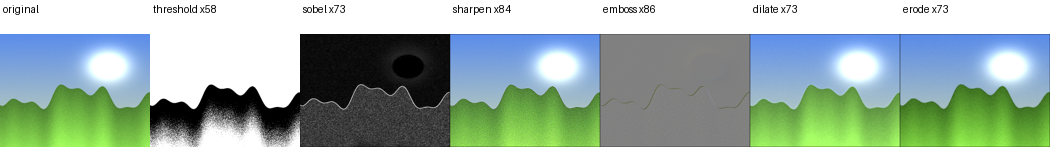

In [3]:
import pandas as pd
img2 = rgb0.reshape(H0, W0 * 3)
def _run(fn, thr=384):
    o = np.zeros_like(img2)
    if fn in (threshold_lum, threshold_lum_py):
        fn(img2, o, H0, W0, thr)
    else:
        fn(img2, o, H0, W0)
    return o
def med(call, k):
    xs = []
    for _ in range(k):
        t0 = time.perf_counter(); call(); xs.append((time.perf_counter() - t0) * 1e3)
    return sorted(xs)[len(xs) // 2]

rows = []; previews = []; labels = []
for name, (kw, kp) in FILTERS.items():
    kw(img2, np.zeros_like(img2), H0, W0, 384) if kw is threshold_lum else kw(img2, np.zeros_like(img2), H0, W0)  # warm
    ow = _run(kw); op = _run(kp)
    tw = med(lambda: _run(kw), 5); tp = med(lambda: _run(kp), 2)
    rows.append({'filter': name, 'plain Python (ms)': round(tp, 1), '@wasm (ms)': round(tw, 1),
                 'speedup': f'x{tp / tw:.0f}', '@wasm == Python': bool(np.array_equal(ow, op))})
    previews.append(ow.reshape(H0, W0, 3)); labels.append(f'{name} x{tp / tw:.0f}')
display(pd.DataFrame(rows).set_index('filter'))

def strip(images, labels, cell=150):
    s = Image.new('RGB', (cell * len(images), cell + 16), 'white'); d = ImageDraw.Draw(s)
    for i, (im, lab) in enumerate(zip(images, labels)):
        t = Image.fromarray(im).copy(); t.thumbnail((cell, cell))
        s.paste(t, (i * cell + (cell - t.width) // 2, 16 + (cell - t.height) // 2)); d.text((i * cell + 3, 3), lab, fill='black')
    return s
display(strip([rgb0] + previews, ['original'] + labels))

## The lab — plain-Python slider vs `@wasm` slider (3-column, single view)

Pick a filter, then drag **both** sliders. Left column = plain Python (the slow one), right column =
`@wasm` (instant). Every run is recorded; the **metrics cell below** shows the median speedup.

In [4]:
import gradio as gr

RUN_METRICS = []   # every slider run; the metrics cell aggregates median time + speedup

def _apply(image, filt, thr, path):
    rgb = np.ascontiguousarray(image, dtype=np.uint8)
    h, w = rgb.shape[:2]; im = rgb.reshape(h, w * 3); out = np.zeros_like(im)
    kw, kp = FILTERS[filt]; fn = kw if path == '@wasm' else kp
    t0 = time.perf_counter()
    if filt == 'threshold':
        fn(im, out, h, w, int(thr) * 3)
    else:
        fn(im, out, h, w)
    dt = (time.perf_counter() - t0) * 1e3
    RUN_METRICS.append({'path': path, 'filter': filt, 'ms': dt})
    return out.reshape(h, w, 3), f'{path}: {dt:.1f} ms   (run #{len(RUN_METRICS)})'

def run_py(image, filt, thr):
    return _apply(image, filt, thr, 'plain Python') if image is not None else (gr.skip(), '')
def run_wasm(image, filt, thr):
    return _apply(image, filt, thr, '@wasm') if image is not None else (gr.skip(), '')

with gr.Blocks(title='pythscribe @wasm image-filter lab') as lab:
    gr.Markdown('### `@wasm` image-filter lab — plain Python (middle) vs `@wasm` (right)')
    with gr.Row(equal_height=True):
        with gr.Column(scale=1, min_width=220):
            gr.Markdown('**input**')
            inp = gr.Image(type='numpy', value=rgb0, height=220, show_label=False)
            filt = gr.Dropdown(list(FILTERS), value='sobel', label='filter')
        with gr.Column(scale=1, min_width=220):
            gr.Markdown('**plain Python** — the slow slider')
            s_py = gr.Slider(0, 255, value=128, step=1, label='drag me (threshold / re-run)')
            out_py = gr.Image(type='numpy', height=220, show_label=False)
            box_py = gr.Textbox(show_label=False, interactive=False)
        with gr.Column(scale=1, min_width=220):
            gr.Markdown('**`@wasm`** — the fast slider')
            s_w = gr.Slider(0, 255, value=128, step=1, label='drag me (threshold / re-run)')
            out_w = gr.Image(type='numpy', height=220, show_label=False)
            box_w = gr.Textbox(show_label=False, interactive=False)
    s_py.release(run_py, [inp, filt, s_py], [out_py, box_py])
    s_w.release(run_wasm, [inp, filt, s_w], [out_w, box_w])
    filt.change(run_py, [inp, filt, s_py], [out_py, box_py])
    filt.change(run_wasm, [inp, filt, s_w], [out_w, box_w])
    lab.load(run_wasm, [inp, filt, s_w], [out_w, box_w])

lab.launch(inbrowser=True)

C:\Users\DELL\anaconda3\envs\pyths-gradio\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7873
* To create a public link, set `share=True` in `launch()`.


## Run metrics — median time + speedup across every slider run

After dragging both sliders (try several filters), run this cell. It aggregates **all recorded runs**
into median plain-Python time, median `@wasm` time, and median speedup, per filter.

In [5]:
if not RUN_METRICS:
    print('No runs yet — drag both sliders in the lab above, then re-run this cell.')
else:
    df = pd.DataFrame(RUN_METRICS); rows = []
    for filt in df['filter'].unique():
        sub = df[df['filter'] == filt]
        py = sub[sub['path'] == 'plain Python']['ms']; wa = sub[sub['path'] == '@wasm']['ms']
        rows.append({'filter': filt,
                     'plain Python median (ms)': round(py.median(), 1) if len(py) else float('nan'),
                     '@wasm median (ms)': round(wa.median(), 1) if len(wa) else float('nan'),
                     'runs (py / @wasm)': f'{len(py)} / {len(wa)}',
                     'median speedup': (f'x{py.median() / wa.median():.0f}' if len(py) and len(wa) else '—')})
    print(f'total runs recorded: {len(RUN_METRICS)}')
    display(pd.DataFrame(rows).set_index('filter'))

No runs yet — drag both sliders in the lab above, then re-run this cell.


## Bonus — a *different* kind of win: zero-round-trip (`@wasm` in the browser)

Not every `@wasm` win is a 50× speedup. A scalar kernel can run **in the browser tab** with no server
hop at all — instant, offline. Here a loan-payment formula computes in the page (`path=browser-wasm`,
`server ran Python: 0`); each run is recorded too.

In [6]:
@wasm
def monthly_payment(principal: float, annual_rate_pct: float, months: int) -> float:
    r = annual_rate_pct / 1200.0
    if r == 0.0:
        return principal / months
    factor = 1.0
    base = 1.0 + r
    i = 0
    while i < months:
        factor = factor * base
        i = i + 1
    return principal * r * factor / (factor - 1.0)

from pythscribe.gradio import WasmFunction, dispatch, result_of
CALC_RUNS = []

def _compute(principal, rate, months):
    return dispatch(monthly_payment, float(principal), float(rate), int(months))

def _show(payload):
    r = result_of(monthly_payment, payload)
    if r is None or r.get('value') is None:
        return gr.skip()
    CALC_RUNS.append({'path': r.get('path'), 'server_python_calls': r.get('python_calls')})
    return (f"${r['value']:,.2f} / month   (run #{len(CALC_RUNS)}: computed in your browser "
            f"— path={r.get('path')}, server ran Python: {r.get('python_calls')})")

with gr.Blocks(title='pythscribe @wasm — zero-round-trip calculator') as calc:
    gr.HTML('<style>.wasm-payload{display:none !important}</style>')
    gr.Markdown('### Loan calculator — the formula runs in **your browser** (`@wasm`, no server hop)')
    with gr.Row():
        principal = gr.Slider(10000, 1000000, value=300000, step=10000, label='principal ($)')
        rate = gr.Slider(0.5, 15.0, value=6.0, step=0.1, label='annual rate (%)')
        months = gr.Slider(12, 480, value=360, step=12, label='term (months)')
    comp = WasmFunction(label='monthly_payment (@wasm, in your tab)')
    out = gr.Textbox(label='monthly payment', interactive=False)
    for sl in (principal, rate, months):
        sl.change(_compute, [principal, rate, months], [comp])
    comp.change(_show, [comp], [out])
    calc.load(_compute, [principal, rate, months], [comp])

calc.launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7874
* To create a public link, set `share=True` in `launch()`.


## Recap

- **Six per-pixel filters, ~50–100× over plain Python**, bit-for-bit correct — fast enough that the
  `@wasm` slider feels instant while the plain-Python slider crawls. These make a strong primary demo.
- **Zero-round-trip**: a scalar `@wasm` kernel runs in the browser tab with no server hop — a different
  kind of win (latency, offline), not raw speedup.

See `gradio_demo.ipynb` (image downscale, 3 modes + headless-browser timing) and
`full_features_demo.ipynb` (speed / memory / capability tables) for more.